# FCN3 vs GraphCast vs Pangu vs HRES: 10 m Wind Speed – 2022 (+12 h Lead)

Compares four forecast models against hourly station observations.

**Aligned period:** 2022-01-01 → 2022-01-28
**Valid time:** 12:00 UTC daily | **Init:** 00:00 UTC | **Lead:** +12 h

| Model | Source | Init | Lead | Valid |
|---|---|---|---|---|
| FCN3 | Full-grid multistep zarr (fcn3_station_weekly_multistep_2022) | 00:00 UTC | +12 h | 12:00 UTC |
| GraphCast | Station multistep zarr (graphcast_operational_station_weekly_multistep_2022) | 00:00 UTC | +12 h | 12:00 UTC |
| HRES | ECMWF WeatherBench2 0.25° | 00:00 UTC | +12 h | 12:00 UTC |
| Pangu | Pangu-Weather WeatherBench2 0.25° | 00:00 UTC | +12 h | 12:00 UTC |

| Station ID | Name | Lat | Lon |
|---|---|---|---|
| SN88690 | Hekkingen Fyr | 69.60 N | 17.83 E |
| SN90490 | Tromsø-Langnes | 69.68 N | 18.91 E |
| SN90760 | Fakken | 70.10 N | 20.11 E |


In [1]:
import warnings
warnings.filterwarnings('ignore')

# nest_asyncio lets zarr v3 async code run inside Jupyter's existing event loop
import nest_asyncio
nest_asyncio.apply()

import zarr
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

print('zarr  :', zarr.__version__)
print('numpy :', np.__version__)
print('pandas:', pd.__version__)
print('xarray:', xr.__version__)


zarr  : 3.1.6
numpy : 2.4.4
pandas: 3.0.3
xarray: 2026.4.0


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
FCN3_DIR   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/fcn3_station_weekly_multistep_2022')
GC_DIR     = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/graphcast_operational_station_weekly_multistep_2022')
HRES_PATH  = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/hres/0p25/2016-2022-0012-1440x721.zarr')
PANGU_PATH = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/pangu/0p25/2018-2022_0012_0p25.zarr')
OBS_DIR    = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')

FIG_DIR = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

# ── Experiment settings ─────────────────────────────────────────────────────
# All models compared at valid_time = 12:00 UTC, init = 00:00 UTC, lead = +12h.
# FCN3: full global grid multistep, daily 00:00 UTC init, lead=12h.
# GC:   pre-extracted station multistep, 6-hourly inits; filtered to 00:00 UTC init.
# HRES/Pangu: WeatherBench2, 00:00 UTC init, lead=12h.
LEAD_H       = 12
PERIOD_START = '2022-01-01'
PERIOD_END   = '2022-01-28'

# ── Station metadata ────────────────────────────────────────────────────────
STATIONS = {
    'SN88690': {'name': 'Hekkingen Fyr',  'lat': 69.6005,  'lon': 17.8317},
    'SN90490': {'name': 'Tromsø-Langnes', 'lat': 69.6767,  'lon': 18.9133},
    'SN90760': {'name': 'Fakken',          'lat': 70.10426, 'lon': 20.11451},
}

OBS_STATION_NAMES = {
    'SN88690': 'SN88690_Hekkingen_Fyr',
    'SN90490': 'SN90490_Tromsoe_Langnes',
    'SN90760': 'SN90760_Fakken',
}

CLR = {
    'FCN3':      '#E74C3C',
    'GraphCast': '#2980B9',
    'Pangu':     '#16A085',
    'HRES':      '#E67E22',
    'Obs':       '#27AE60',
}


Figures → /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h


## 1  Load Observations

In [3]:
def load_observations(obs_dir: Path, obs_station_names: dict,
                      start: str, end: str) -> pd.DataFrame:
    """Load hourly per-year obs CSVs and compute 12-hour trailing mean per station.

    obs_station_names: {station_id: file_base_name}
      e.g. 'SN88690' -> 'SN88690_Hekkingen_Fyr'
    Files are expected as <base_name>_<year>.csv.
    """
    start_yr = pd.Timestamp(start).year
    end_yr   = pd.Timestamp(end).year

    dfs = []
    for sid, base in obs_station_names.items():
        parts = []
        for yr in range(start_yr, end_yr + 1):
            f = obs_dir / f'{base}_{yr}.csv'
            if not f.exists():
                print(f'  Warning: {f.name} not found, skipping.')
                continue
            df = pd.read_csv(f)
            df['valid_time'] = pd.to_datetime(df['time'], utc=True).dt.tz_localize(None)
            df['station'] = sid
            df = df.rename(columns={'wind_speed': 'obs_wind'})
            parts.append(df[['station', 'valid_time', 'obs_wind']].dropna(subset=['obs_wind']))

        if not parts:
            continue

        sdf = pd.concat(parts, ignore_index=True).sort_values('valid_time')
        # 12-hour trailing mean; require at least 6 obs in window
        sdf['obs_wind'] = (
            sdf.set_index('valid_time')['obs_wind']
            .rolling('12h', min_periods=6)
            .mean()
            .values
        )
        dfs.append(sdf.dropna(subset=['obs_wind']))

    obs = pd.concat(dfs, ignore_index=True)
    obs = obs[(obs['valid_time'] >= start) & (obs['valid_time'] <= end)]
    return obs


obs_df = load_observations(OBS_DIR, OBS_STATION_NAMES, PERIOD_START, PERIOD_END)
print(f'Observations (12h trailing mean): {len(obs_df):,} rows')
print(f'  Time range : {obs_df["valid_time"].min()} → {obs_df["valid_time"].max()}')
obs_df.head(3)


Observations (12h trailing mean): 1,917 rows
  Time range : 2022-01-01 05:00:00 → 2022-01-28 00:00:00


,station,valid_time,obs_wind
0,SN88690,2022-01-01 05:00:00,7.65
1,SN88690,2022-01-01 06:00:00,8.20
2,SN88690,2022-01-01 07:00:00,8.40


## 2  Load FCN3 (Multistep Full Grid, +12 h Lead)

In [4]:
def _nearest_idx(arr: np.ndarray, target: float) -> int:
    return int(np.argmin(np.abs(arr - target)))


def load_fcn3_multistep_weekly(zarr_path: Path, stations: dict, lead_h: float) -> pd.DataFrame:
    """Extract station wind speed from one FCN3 multistep weekly zarr (full global grid).
    Uses xr.open_zarr to avoid zarr-v3 async conflicts inside Jupyter.
    """
    ds = xr.open_zarr(str(zarr_path), consolidated=True)

    lats = ds['lat'].values
    lons = ds['lon'].values

    # lead_time may be int hours or timedelta64 depending on how the file was written
    lt_raw = ds['lead_time'].values
    if np.issubdtype(lt_raw.dtype, np.timedelta64):
        lt_hours = (lt_raw / np.timedelta64(1, 'h')).astype(float)
    else:
        lt_hours = lt_raw.astype(float)
    lt_idx  = int(np.argmin(np.abs(lt_hours - lead_h)))
    lt_used = float(lt_hours[lt_idx])

    init_times = pd.DatetimeIndex(ds['time'].values)

    # u10m / v10m: shape (n_init, n_lead, n_lat, n_lon)
    ws_all = np.sqrt(ds['u10m'].values ** 2 + ds['v10m'].values ** 2)

    records = []
    for sid, info in stations.items():
        lat_i = _nearest_idx(lats, info['lat'])
        lon_i = _nearest_idx(lons, info['lon'])
        for t_i, init_t in enumerate(init_times):
            wind = float(ws_all[t_i, lt_idx, lat_i, lon_i])
            if np.isnan(wind):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': lt_used,
                'valid_time':  init_t + pd.Timedelta(hours=lt_used),
                'fcn3_wind':   wind,
            })
    return pd.DataFrame(records)


import json as _json

def _is_empty_zarr(path: Path) -> bool:
    """Return True if the zarr group has no arrays (failed/incomplete run)."""
    try:
        meta = _json.load(open(path / 'zarr.json'))
        n = len(meta.get('consolidated_metadata', {}).get('metadata', {}))
        return n == 0
    except Exception:
        return True


fcn3_files = sorted(FCN3_DIR.glob('fcn3_station_wind_multistep_*.zarr'))
print(f'FCN3 files found: {len(fcn3_files)}')

fcn3_parts = []
skipped = 0
for f in fcn3_files:
    if _is_empty_zarr(f):
        print(f'  {f.name} ... SKIPPED (empty/failed run)')
        skipped += 1
        continue
    print(f'  {f.name} ...', end=' ', flush=True)
    df = load_fcn3_multistep_weekly(f, STATIONS, lead_h=LEAD_H)
    fcn3_parts.append(df)
    print(f'{len(df)} records')

print(f'\nSkipped {skipped} empty files.')
fcn3_df = (
    pd.concat(fcn3_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)
print(f'FCN3 total  : {len(fcn3_df):,} records')
print(f'Valid range : {fcn3_df["valid_time"].min()} → {fcn3_df["valid_time"].max()}')
fcn3_df.head(3)


FCN3 files found: 13
  fcn3_station_wind_multistep_20220101_20220107.zarr ... 21 records
  fcn3_station_wind_multistep_20220108_20220114.zarr ... 21 records
  fcn3_station_wind_multistep_20220115_20220121.zarr ... 21 records
  fcn3_station_wind_multistep_20220122_20220128.zarr ... 21 records
  fcn3_station_wind_multistep_20220129_20220204.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220205_20220211.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220212_20220218.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220219_20220225.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220226_20220304.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220305_20220311.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220312_20220318.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220319_20220325.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20220

,station,init_time,lead_time_h,valid_time,fcn3_wind
0,SN88690,2022-01-01,12.0,2022-01-01 12:00:00,4.480801
1,SN88690,2022-01-02,12.0,2022-01-02 12:00:00,12.187243
2,SN88690,2022-01-03,12.0,2022-01-03 12:00:00,7.608070


## 3  Load GraphCast (Multistep Station Zarr, +12 h Lead)

In [5]:
def load_station_weekly(zarr_path: Path, lead_h: float, col_name: str) -> pd.DataFrame:
    """Load pre-extracted station zarr (station x time x lead_time).
    lead_time is decoded by xarray as timedelta64[s].
    """
    ds = xr.open_zarr(str(zarr_path), consolidated=True)
    stations   = [str(s) for s in ds['station'].values]
    init_times = pd.DatetimeIndex(ds['time'].values)
    target_lt  = np.timedelta64(int(lead_h * 3600), 's')
    lt_vals    = ds['lead_time'].values
    lt_idx     = int(np.argmin(np.abs(lt_vals - target_lt)))
    lt_used    = float(lt_vals[lt_idx] / np.timedelta64(1, 's')) / 3600.0
    ws = ds['wind_speed_10m'].values
    records = []
    for s_i, sid in enumerate(stations):
        for t_i, init_t in enumerate(init_times):
            wind = float(ws[s_i, t_i, lt_idx])
            if np.isnan(wind):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': lt_used,
                'valid_time':  init_t + pd.Timedelta(hours=lt_used),
                col_name:      wind,
            })
    return pd.DataFrame(records)


gc_files = sorted(GC_DIR.glob('graphcast_station_wind_multistep_*.zarr'))
gc_files = [f for f in gc_files
            if pd.Timestamp(f.name.split('_')[-2]) <= pd.Timestamp(PERIOD_END)]
print(f'GraphCast files in period: {len(gc_files)}')

gc_parts = []
for f in gc_files:
    print(f'  {f.name} ...', end=' ', flush=True)
    df = load_station_weekly(f, lead_h=LEAD_H, col_name='gc_wind')
    gc_parts.append(df)
    print(f'{len(df)} records')

gc_df = (
    pd.concat(gc_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)
# Keep only 12:00 UTC valid times (00:00 UTC init + 12h lead)
gc_df = gc_df[gc_df['valid_time'].dt.hour == 12].reset_index(drop=True)
print(f'GraphCast total (12:00 UTC): {len(gc_df):,}')
gc_df.head(3)


GraphCast files in period: 4
  graphcast_station_wind_multistep_20220101_20220107.zarr ... 84 records
  graphcast_station_wind_multistep_20220108_20220114.zarr ... 84 records
  graphcast_station_wind_multistep_20220115_20220121.zarr ... 84 records
  graphcast_station_wind_multistep_20220122_20220128.zarr ... 84 records
GraphCast total (12:00 UTC): 84


,station,init_time,lead_time_h,valid_time,gc_wind
0,SN88690,2022-01-01,12.0,2022-01-01 12:00:00,2.590131
1,SN88690,2022-01-02,12.0,2022-01-02 12:00:00,9.315088
2,SN88690,2022-01-03,12.0,2022-01-03 12:00:00,7.146975


## 4  Load HRES and Pangu (WeatherBench2)

In [6]:
# ── HRES ────────────────────────────────────────────────────────────────────
hres_ds = xr.open_zarr(HRES_PATH, consolidated=False)
print('HRES time  :', pd.Timestamp(hres_ds['time'].values[0]), '→',
      pd.Timestamp(hres_ds['time'].values[-1]))
print('HRES leads (h, first 6):', hres_ds['prediction_timedelta'].values[:6])


def load_wb2_at_stations(ds: xr.Dataset, wind_var: str, lat_coord: str,
                          lon_coord: str, lead_coord: str,
                          stations: dict, lead_h: int,
                          start: str, end: str, col_name: str) -> pd.DataFrame:
    """Extract nearest-grid-point 10 m wind from a WeatherBench2 zarr."""
    da = ds[wind_var].sel({lead_coord: lead_h})
    da = da.sel(time=slice(start, end))
    init_times = pd.DatetimeIndex(da['time'].values)
    records = []
    for sid, info in stations.items():
        target_lon = info['lon'] % 360
        ws_vals = da.sel(
            {lat_coord: info['lat'], lon_coord: target_lon}, method='nearest'
        ).values
        for t_i, init_t in enumerate(init_times):
            val = float(ws_vals[t_i])
            if np.isnan(val):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': float(lead_h),
                'valid_time':  init_t + pd.Timedelta(hours=float(lead_h)),
                col_name:      val,
            })
    return pd.DataFrame(records)


hres_df = load_wb2_at_stations(
    hres_ds, wind_var='10m_wind_speed',
    lat_coord='latitude', lon_coord='longitude', lead_coord='prediction_timedelta',
    stations=STATIONS, lead_h=12, start=PERIOD_START, end=PERIOD_END,
    col_name='hres_wind',
)
hres_df = (
    hres_df.drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time']).reset_index(drop=True)
)
print(f'HRES records: {len(hres_df):,}')

# ── Pangu ────────────────────────────────────────────────────────────────────
# Pangu latitude runs 90→-90 (descending). method='nearest' handles this correctly.
pangu_ds = xr.open_zarr(PANGU_PATH, consolidated=False)
print('\nPangu time  :', pd.Timestamp(pangu_ds['time'].values[0]), '→',
      pd.Timestamp(pangu_ds['time'].values[-1]))
print('Pangu leads (h, first 6):', pangu_ds['prediction_timedelta'].values[:6])

pangu_df = load_wb2_at_stations(
    pangu_ds, wind_var='10m_wind_speed',
    lat_coord='latitude', lon_coord='longitude', lead_coord='prediction_timedelta',
    stations=STATIONS, lead_h=12, start=PERIOD_START, end=PERIOD_END,
    col_name='pangu_wind',
)
pangu_df = (
    pangu_df.drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time']).reset_index(drop=True)
)
print(f'Pangu records: {len(pangu_df):,}')


HRES time  : 2016-01-01 00:00:00 → 2023-01-10 12:00:00
HRES leads (h, first 6): [ 0  6 12 18 24 30]
HRES records: 168

Pangu time  : 2018-01-01 00:00:00 → 2022-12-31 12:00:00
Pangu leads (h, first 6): [ 6 12 18 24 30 36]
Pangu records: 168


## 4  Align Datasets

In [7]:
for _df in [fcn3_df, gc_df, hres_df, pangu_df, obs_df]:
    _df['valid_time'] = _df['valid_time'].astype('datetime64[us]')

# Merge all four models
merged = fcn3_df[['station', 'valid_time', 'fcn3_wind']].copy()
for right_df, right_col in [
    (gc_df,    'gc_wind'),
    (hres_df,  'hres_wind'),
    (pangu_df, 'pangu_wind'),
]:
    merged = pd.merge(merged, right_df[['station', 'valid_time', right_col]],
                      on=['station', 'valid_time'], how='inner')

print(f'FCN3 ∩ GC ∩ HRES ∩ Pangu       : {len(merged):,}')

merged = pd.merge(
    merged,
    obs_df[['station', 'valid_time', 'obs_wind']],
    on=['station', 'valid_time'], how='inner',
).dropna(subset=['fcn3_wind', 'gc_wind', 'hres_wind', 'pangu_wind', 'obs_wind'])
print(f'All models ∩ Obs               : {len(merged):,}')


if len(merged) == 0:
    raise ValueError('No matching records after merge.')

print(f'\nPer station:')
print(merged.groupby('station').size().rename('N'))
print(f'\nValid-time range : {merged["valid_time"].min()} → {merged["valid_time"].max()}')

_avail   = set(merged['station'].unique())
_missing = [s for s in list(STATIONS.keys()) if s not in _avail]
for s in _missing:
    print(f'  Note: {s} excluded — no overlap.')
    del STATIONS[s]
merged.head(5)


FCN3 ∩ GC ∩ HRES ∩ Pangu       : 84
All models ∩ Obs               : 80

Per station:
station
SN88690    26
SN90490    27
SN90760    27
Name: N, dtype: int64

Valid-time range : 2022-01-01 12:00:00 → 2022-01-27 12:00:00


,station,valid_time,fcn3_wind,gc_wind,hres_wind,pangu_wind,obs_wind
0,SN88690,2022-01-01 12:00:00,4.480801,2.590131,2.044611,3.123874,6.883333
1,SN88690,2022-01-02 12:00:00,12.187243,9.315088,8.616384,10.554110,16.650000
2,SN88690,2022-01-03 12:00:00,7.608070,7.146975,6.156938,6.961180,12.900000
3,SN88690,2022-01-04 12:00:00,3.538550,4.001620,4.293141,4.035882,6.716667
4,SN88690,2022-01-05 12:00:00,6.776317,4.887294,2.707551,3.224736,8.083333


## 5  Compute Metrics

In [8]:
MODEL_COLS = {
    'FCN3':      'fcn3_wind',
    'GraphCast': 'gc_wind',
    'HRES':      'hres_wind',
    'Pangu':     'pangu_wind',
}


def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for label, gdf in [*df.groupby('station'), ('All Stations', df)]:
        if len(gdf) == 0:
            continue
        row = {'Station': label, 'N': len(gdf)}
        for mname, wcol in MODEL_COLS.items():
            if wcol not in gdf.columns:
                continue
            sub = gdf.dropna(subset=[wcol])
            if len(sub) == 0:
                continue
            e = sub[wcol] - sub['obs_wind']
            row[f'{mname} RMSE'] = float(np.sqrt((e**2).mean()))
            row[f'{mname} MSE']  = float((e**2).mean())
            row[f'{mname} Bias'] = float(e.mean())
        rows.append(row)
    return pd.DataFrame(rows).set_index('Station')


metrics = compute_metrics(merged)
rmse_cols = [f'{m} RMSE' for m in MODEL_COLS if f'{m} RMSE' in metrics.columns]
mse_cols  = [f'{m} MSE'  for m in MODEL_COLS if f'{m} MSE'  in metrics.columns]
bias_cols = [f'{m} Bias' for m in MODEL_COLS if f'{m} Bias' in metrics.columns]

print('=' * 110)
print(f'Fair Comparison  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}')
print('=' * 110)
print(metrics[['N', *rmse_cols]].round(4).to_string())
print()
print(metrics[['N', *bias_cols]].round(4).to_string())


Fair Comparison  |  lead = +12 h  |  2022-01-01 → 2022-01-28
               N  FCN3 RMSE  GraphCast RMSE  HRES RMSE  Pangu RMSE
Station                                                           
SN88690       26     3.4137          3.9718     5.2953      3.6972
SN90490       27     3.8582          3.7023     4.0051      3.2600
SN90760       27     7.1233          7.5934     7.3187      7.6117
All Stations  80     5.0928          5.4049     5.7100      5.2520

               N  FCN3 Bias  GraphCast Bias  HRES Bias  Pangu Bias
Station                                                           
SN88690       26    -2.6220         -3.1958    -4.6672     -2.8022
SN90490       27    -3.0091         -3.0232    -3.2906     -2.3904
SN90760       27    -5.5375         -6.1375    -5.5803     -6.0846
All Stations  80    -3.7366         -4.1304    -4.5108     -3.7710


## 6  Time Series

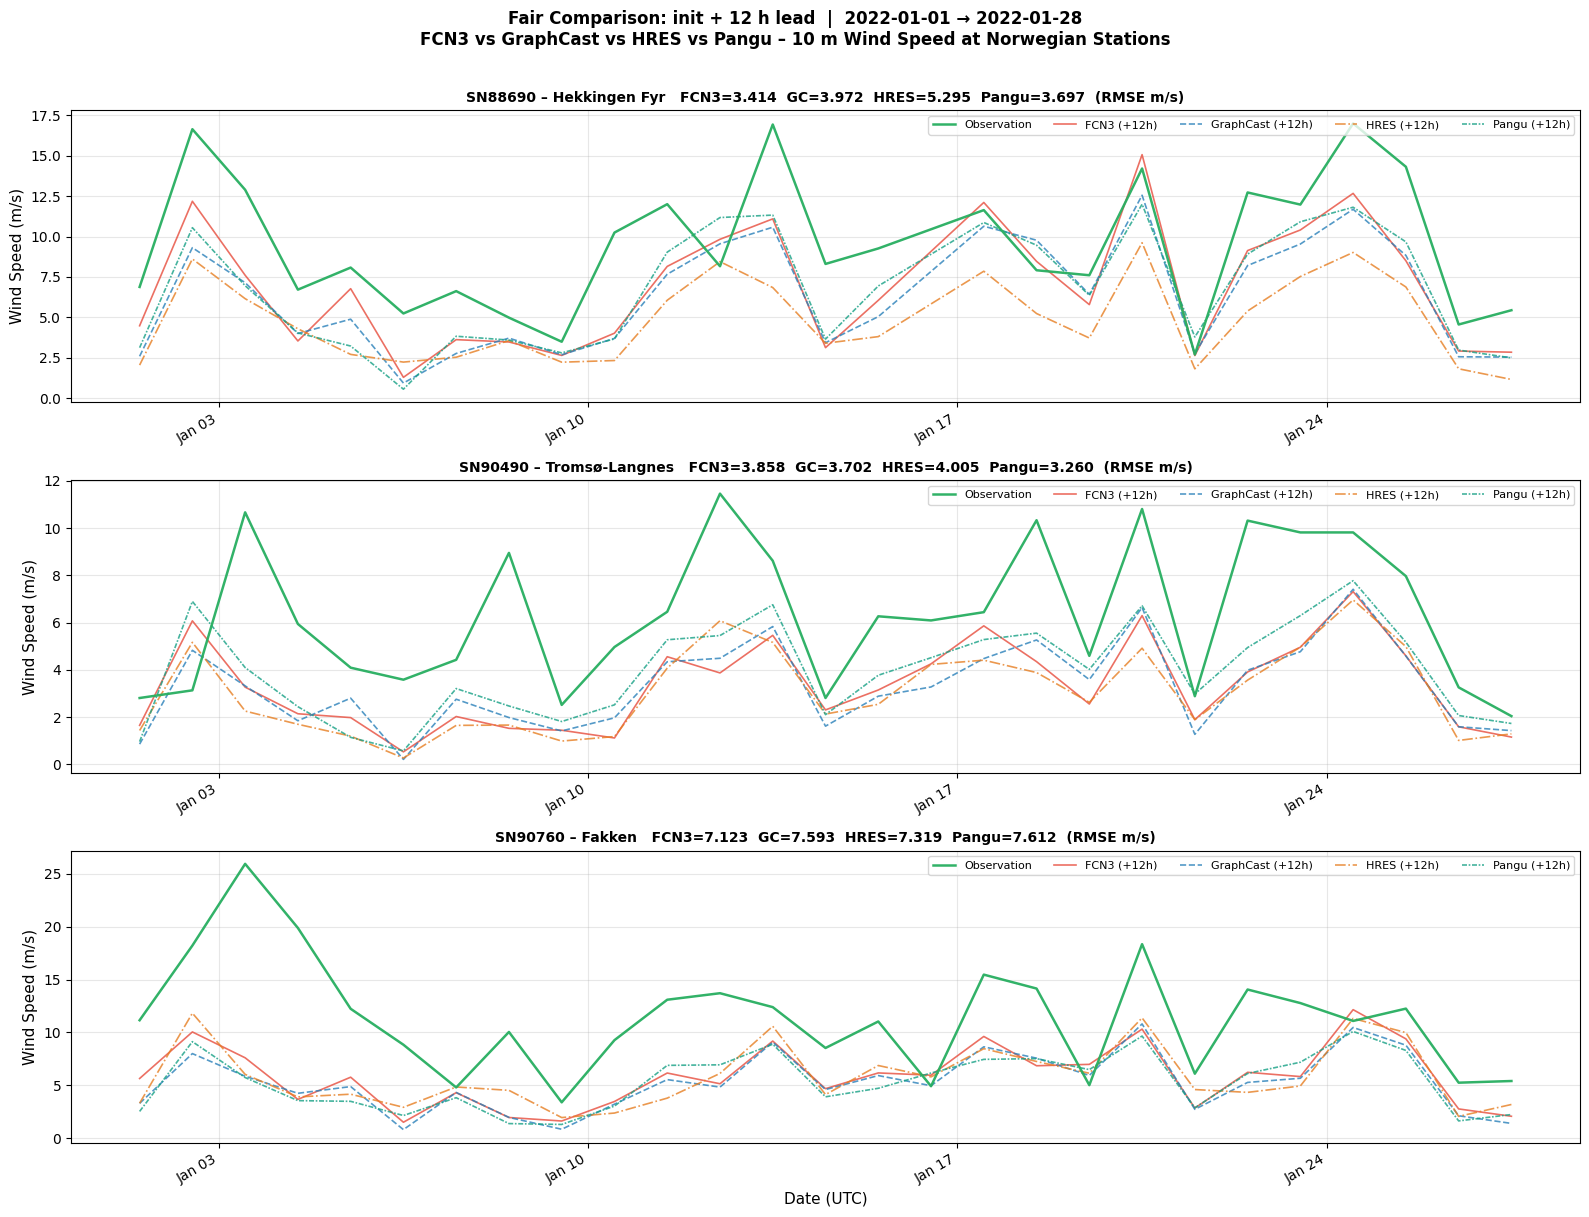

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/comparison_time_series.png


In [9]:
_n   = len(STATIONS)
fig, axes = plt.subplots(_n, 1, figsize=(16, 4 * _n))
if _n == 1:
    axes = [axes]

for ax, (sid, info) in zip(axes, STATIONS.items()):
    sub = merged[merged['station'] == sid].sort_values('valid_time')
    ax.plot(sub['valid_time'], sub['obs_wind'],
            color=CLR['Obs'],  lw=1.8, label='Observation', alpha=0.95, zorder=5)
    ax.plot(sub['valid_time'], sub['fcn3_wind'],
            color=CLR['FCN3'],      lw=1.2, label=f'FCN3 (+{LEAD_H}h)',      alpha=0.80, zorder=2)
    ax.plot(sub['valid_time'], sub['gc_wind'],
            color=CLR['GraphCast'], lw=1.2, label=f'GraphCast (+{LEAD_H}h)', alpha=0.80, zorder=3, linestyle='--')
    ax.plot(sub['valid_time'], sub['hres_wind'],
            color=CLR['HRES'],  lw=1.2, label=f'HRES (+{LEAD_H}h)',  alpha=0.80, zorder=3, linestyle='-.')
    ax.plot(sub['valid_time'], sub['pangu_wind'],
            color=CLR['Pangu'], lw=1.2, label=f'Pangu (+{LEAD_H}h)', alpha=0.80, zorder=3, linestyle=(0, (3, 1, 1, 1)))

    rf = metrics.loc[sid, 'FCN3 RMSE']
    rg = metrics.loc[sid, 'GraphCast RMSE']
    rh = metrics.loc[sid, 'HRES RMSE']
    rp = metrics.loc[sid, 'Pangu RMSE']
    ax.set_title(
        f'{sid} – {info["name"]}   FCN3={rf:.3f}  GC={rg:.3f}  HRES={rh:.3f}  Pangu={rp:.3f}  (RMSE m/s)',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, ncol=5)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[-1].set_xlabel('Date (UTC)', fontsize=11)
fig.suptitle(
    f'Fair Comparison: init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}\n'
    'FCN3 vs GraphCast vs HRES vs Pangu – 10 m Wind Speed at Norwegian Stations',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
out = FIG_DIR / 'comparison_time_series.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 7  Error Bar Charts

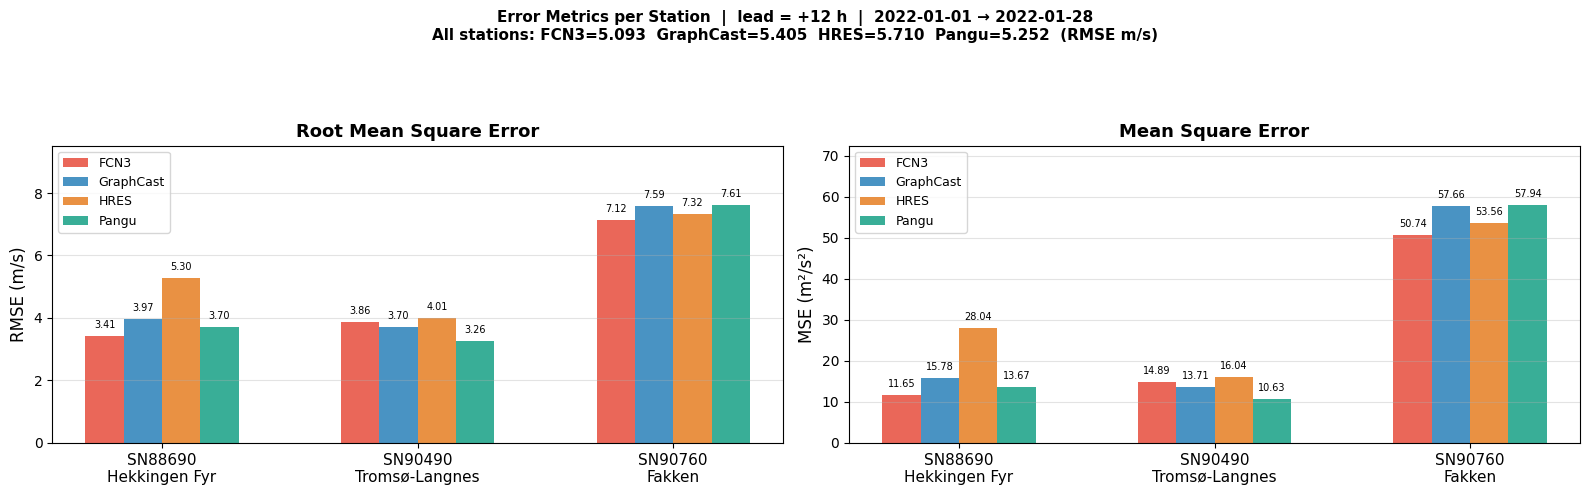

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/comparison_metrics_bar.png


In [10]:
sids    = list(STATIONS.keys())
labels  = [f'{s}\n{STATIONS[s]["name"]}' for s in sids]
mdf     = metrics.loc[sids]
models  = ['FCN3', 'GraphCast', 'HRES', 'Pangu']
present = [m for m in models if f'{m} RMSE' in mdf.columns]
x       = np.arange(len(sids))
w       = 0.15
offsets = np.linspace(-(len(present) - 1) / 2, (len(present) - 1) / 2, len(present)) * w

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (metric, ylabel, title) in zip(
    axes,
    [('RMSE', 'RMSE (m/s)',   'Root Mean Square Error'),
     ('MSE',  'MSE (m²/s²)', 'Mean Square Error')],
):
    all_bars = []
    for m, offset in zip(present, offsets):
        bars = ax.bar(x + offset, mdf[f'{m} {metric}'], w,
                      label=m, color=CLR[m], alpha=0.85)
        all_bars.extend(bars)

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.35)
    max_h = max(b.get_height() for b in all_bars)
    for b in all_bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max_h * 0.025,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_ylim(0, max_h * 1.25)

ov = metrics.loc['All Stations']
parts = [f'{m}={ov[f"{m} RMSE"]:.3f}' for m in present if f'{m} RMSE' in ov]
fig.suptitle(
    f'Error Metrics per Station  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}\n'
    'All stations: ' + '  '.join(parts) + '  (RMSE m/s)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
out = FIG_DIR / 'comparison_metrics_bar.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 8  Scatter Plots (Obs vs Predicted)

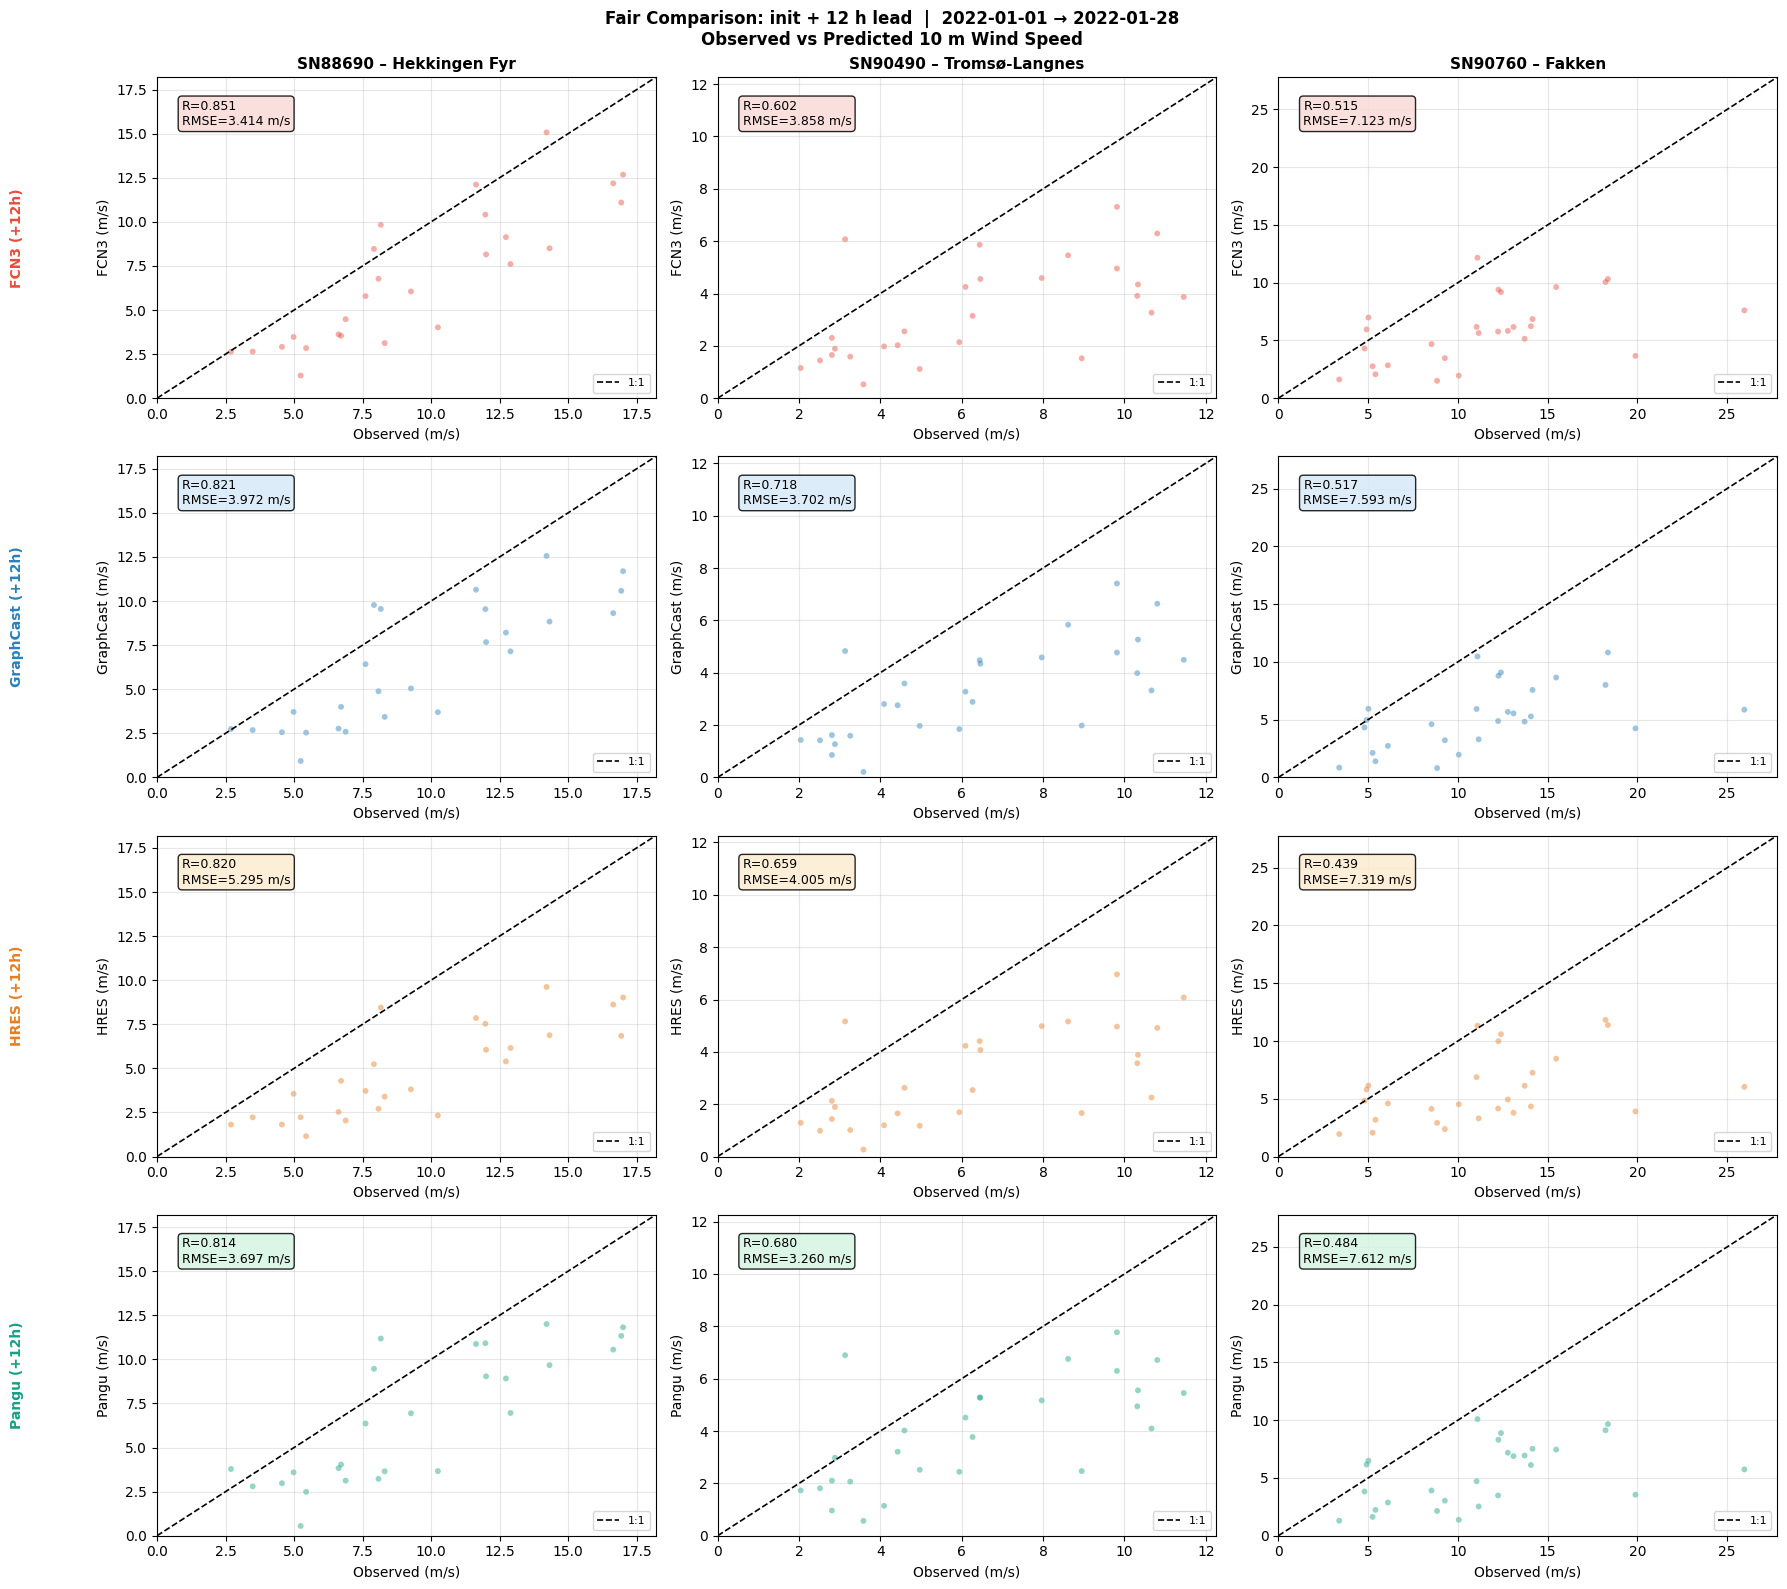

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/comparison_scatter.png


In [11]:
model_rows = [
    ('fcn3_wind',  'FCN3',      'FCN3 RMSE',      CLR['FCN3'],      '#FADBD8'),
    ('gc_wind',    'GraphCast', 'GraphCast RMSE',  CLR['GraphCast'], '#D6EAF8'),
    ('hres_wind',  'HRES',      'HRES RMSE',       CLR['HRES'],      '#FDEBD0'),
    ('pangu_wind', 'Pangu',     'Pangu RMSE',      CLR['Pangu'],     '#D5F5E3'),
]
_n   = len(STATIONS)
_m   = len(model_rows)
fig, axes = plt.subplots(_m, _n, figsize=(5 * _n + 3, 4 * _m), squeeze=False)

for col, (sid, info) in enumerate(STATIONS.items()):
    sub  = merged[merged['station'] == sid]
    vmax = max(sub[['obs_wind', 'fcn3_wind', 'gc_wind', 'hres_wind', 'pangu_wind']].max()) * 1.07

    for row_i, (wind_col, label, rmse_key, clr, fc) in enumerate(model_rows):
        ax = axes[row_i, col]
        ax.scatter(sub['obs_wind'], sub[wind_col], alpha=0.45, s=18, color=clr, edgecolors='none')
        ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
        ax.set_xlabel('Observed (m/s)', fontsize=10)
        ax.set_ylabel(f'{label} (m/s)', fontsize=10)
        if row_i == 0:
            ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
        r = np.corrcoef(sub['obs_wind'], sub[wind_col])[0, 1]
        ax.text(0.05, 0.93, f'R={r:.3f}\nRMSE={metrics.loc[sid, rmse_key]:.3f} m/s',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor=fc, alpha=0.85))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0.05, 0, 1, 0.97])
for row_i, (_, label, _, clr, _) in enumerate(model_rows):
    bbox  = axes[row_i, 0].get_position()
    y_mid = (bbox.y0 + bbox.y1) / 2
    fig.text(0.01, y_mid, f'{label} (+{LEAD_H}h)', va='center', rotation='vertical',
             fontsize=10, fontweight='bold', color=clr)

fig.suptitle(
    f'Fair Comparison: init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}\n'
    'Observed vs Predicted 10 m Wind Speed',
    fontsize=12, fontweight='bold', y=0.99
)
out = FIG_DIR / 'comparison_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 9  Accuracy Scatter (+/-2 m/s Tolerance Band) – All Models Combined

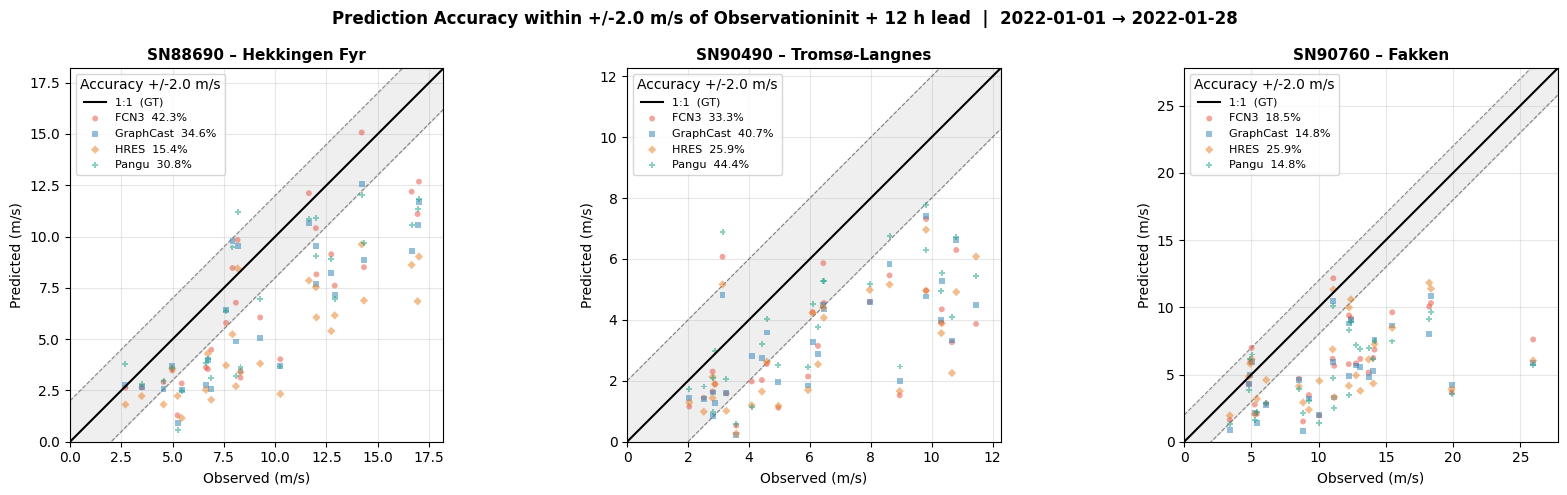

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/comparison_accuracy_scatter.png


In [13]:
TOLERANCE = 2.0  # m/s

_n   = len(STATIONS)
fig, axes = plt.subplots(1, _n, figsize=(5 * _n + 2, 5), squeeze=False)
axes = axes[0]

model_layers = [
    ('fcn3_wind',  'FCN3',      CLR['FCN3'],      'o'),
    ('gc_wind',    'GraphCast', CLR['GraphCast'], 's'),
    ('hres_wind',  'HRES',      CLR['HRES'],      'D'),
    ('pangu_wind', 'Pangu',     CLR['Pangu'],     'P'),
]

for col, (sid, info) in enumerate(STATIONS.items()):
    ax   = axes[col]
    sub  = merged[merged['station'] == sid]
    vmax = max(sub[['obs_wind', 'fcn3_wind', 'gc_wind',
                     'hres_wind', 'pangu_wind']].max()) * 1.07
    x    = np.linspace(0, vmax, 200)

    ax.fill_between(x, x - TOLERANCE, x + TOLERANCE,
                    alpha=0.12, color='gray', zorder=1)
    ax.plot(x, x + TOLERANCE, 'k--', lw=0.8, alpha=0.45, zorder=2)
    ax.plot(x, x - TOLERANCE, 'k--', lw=0.8, alpha=0.45, zorder=2)
    ax.plot(x, x, 'k-', lw=1.5, label='1:1  (GT)', zorder=5)

    for wind_col, label, clr, marker in model_layers:
        if wind_col not in sub.columns:
            continue
        s2 = sub.dropna(subset=[wind_col])
        obs_v  = s2['obs_wind'].values
        pred_v = s2[wind_col].values
        acc    = 100.0 * (np.abs(pred_v - obs_v) <= TOLERANCE).mean()
        ax.scatter(obs_v, pred_v, alpha=0.50, s=18, color=clr, marker=marker,
                   edgecolors='none', zorder=3,
                   label=f'{label}  {acc:.1f}%')

    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Observed (m/s)', fontsize=10)
    ax.set_ylabel('Predicted (m/s)', fontsize=10)
    ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left', title=f'Accuracy +/-{TOLERANCE} m/s')
    ax.grid(alpha=0.3)

fig.suptitle(
    f'Prediction Accuracy within +/-{TOLERANCE} m/s of Observation'
    f'init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
out = FIG_DIR / 'comparison_accuracy_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 10  Accuracy Scatter per Model

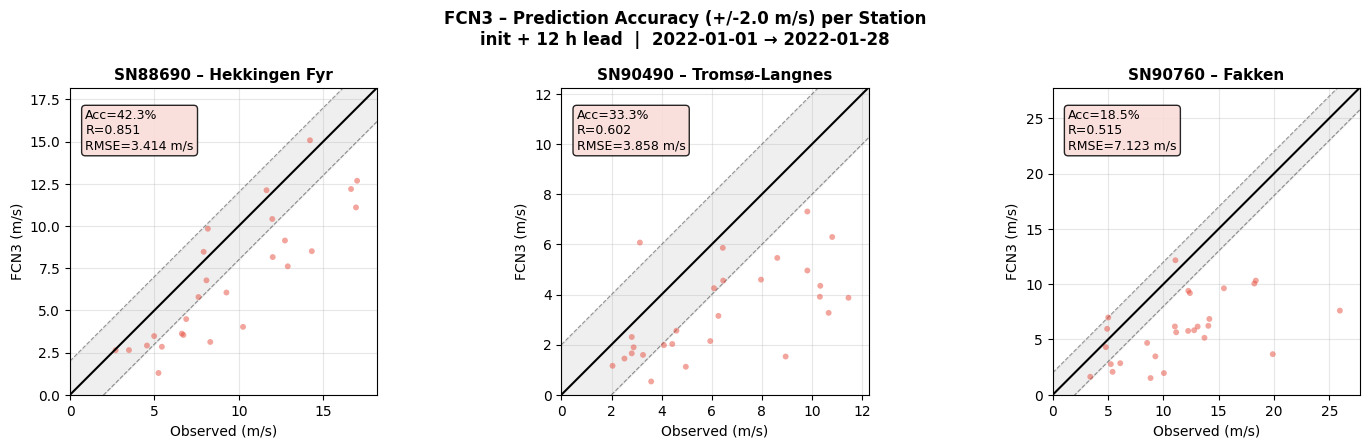

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/accuracy_fcn3_per_station.png


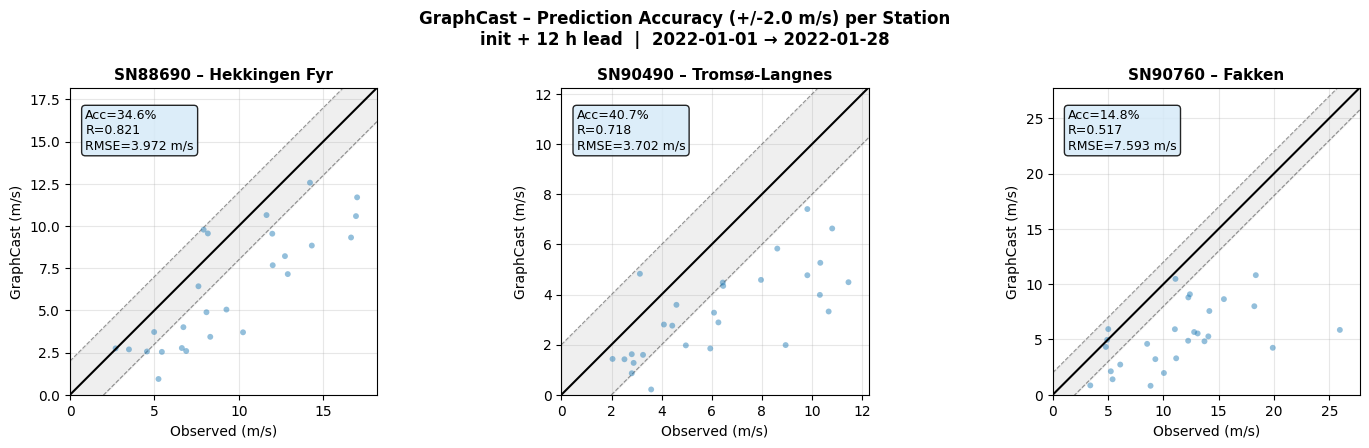

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/accuracy_graphcast_per_station.png


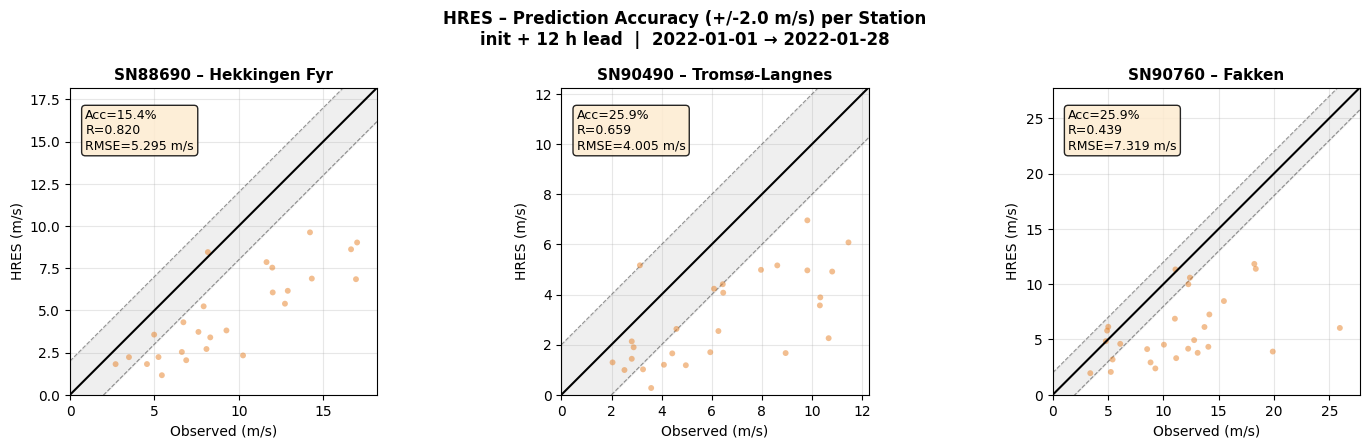

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/accuracy_hres_per_station.png


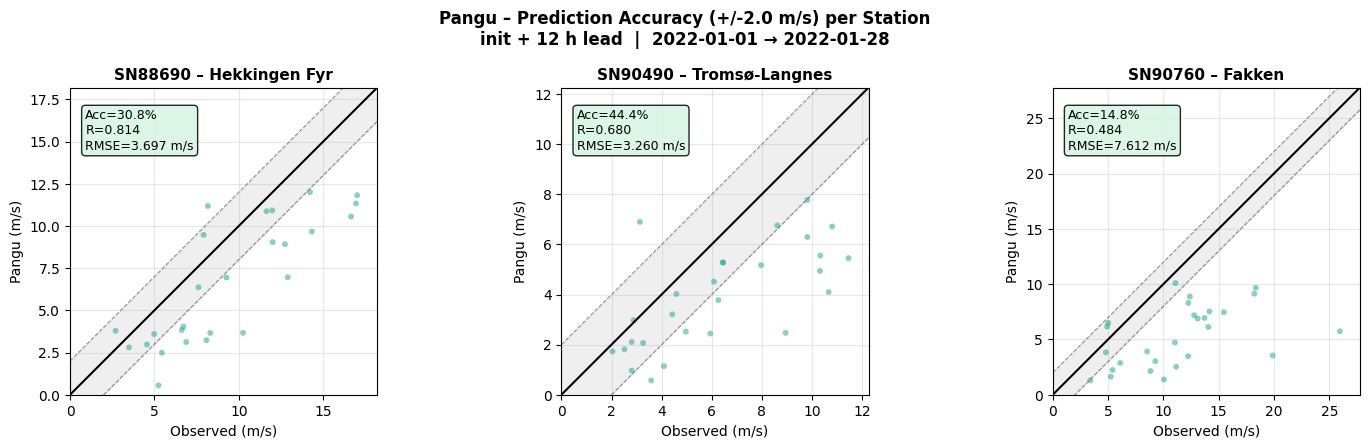

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/accuracy_pangu_per_station.png


In [14]:
TOLERANCE = 2.0
model_list = [
    ('fcn3_wind',  'FCN3',      CLR['FCN3'],      '#FADBD8'),
    ('gc_wind',    'GraphCast', CLR['GraphCast'], '#D6EAF8'),
    ('hres_wind',  'HRES',      CLR['HRES'],      '#FDEBD0'),
    ('pangu_wind', 'Pangu',     CLR['Pangu'],     '#D5F5E3'),
]

for wind_col, model_name, clr, fc in model_list:
    _n = len(STATIONS)
    fig, axes = plt.subplots(1, _n, figsize=(5 * _n, 4.5), squeeze=False)
    axes = axes[0]
    for col, (sid, info) in enumerate(STATIONS.items()):
        ax  = axes[col]
        sub = merged[merged['station'] == sid].dropna(subset=[wind_col])
        vmax = max(sub['obs_wind'].max(), sub[wind_col].max()) * 1.07
        x = np.linspace(0, vmax, 200)
        ax.fill_between(x, x - TOLERANCE, x + TOLERANCE, alpha=0.12, color='gray', zorder=1)
        ax.plot(x, x + TOLERANCE, 'k--', lw=0.8, alpha=0.4, zorder=2)
        ax.plot(x, x - TOLERANCE, 'k--', lw=0.8, alpha=0.4, zorder=2)
        ax.plot(x, x, 'k-', lw=1.5, zorder=5)
        obs_v  = sub['obs_wind'].values
        pred_v = sub[wind_col].values
        acc  = 100.0 * (np.abs(pred_v - obs_v) <= TOLERANCE).mean()
        r    = np.corrcoef(obs_v, pred_v)[0, 1]
        rmse = float(np.sqrt(np.mean((pred_v - obs_v) ** 2)))
        ax.scatter(obs_v, pred_v, alpha=0.5, s=18, color=clr, edgecolors='none', zorder=3)
        ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('Observed (m/s)', fontsize=10)
        ax.set_ylabel(f'{model_name} (m/s)', fontsize=10)
        ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
        ax.text(0.05, 0.93, f'Acc={acc:.1f}%\nR={r:.3f}\nRMSE={rmse:.3f} m/s',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor=fc, alpha=0.85))
        ax.grid(alpha=0.3)
    fig.suptitle(
        f'{model_name} – Prediction Accuracy (+/-{TOLERANCE} m/s) per Station\n'
        f'init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    out = FIG_DIR / f'accuracy_{model_name.lower()}_per_station.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


## 11  High-Wind Events (>= 10.8 m/s)

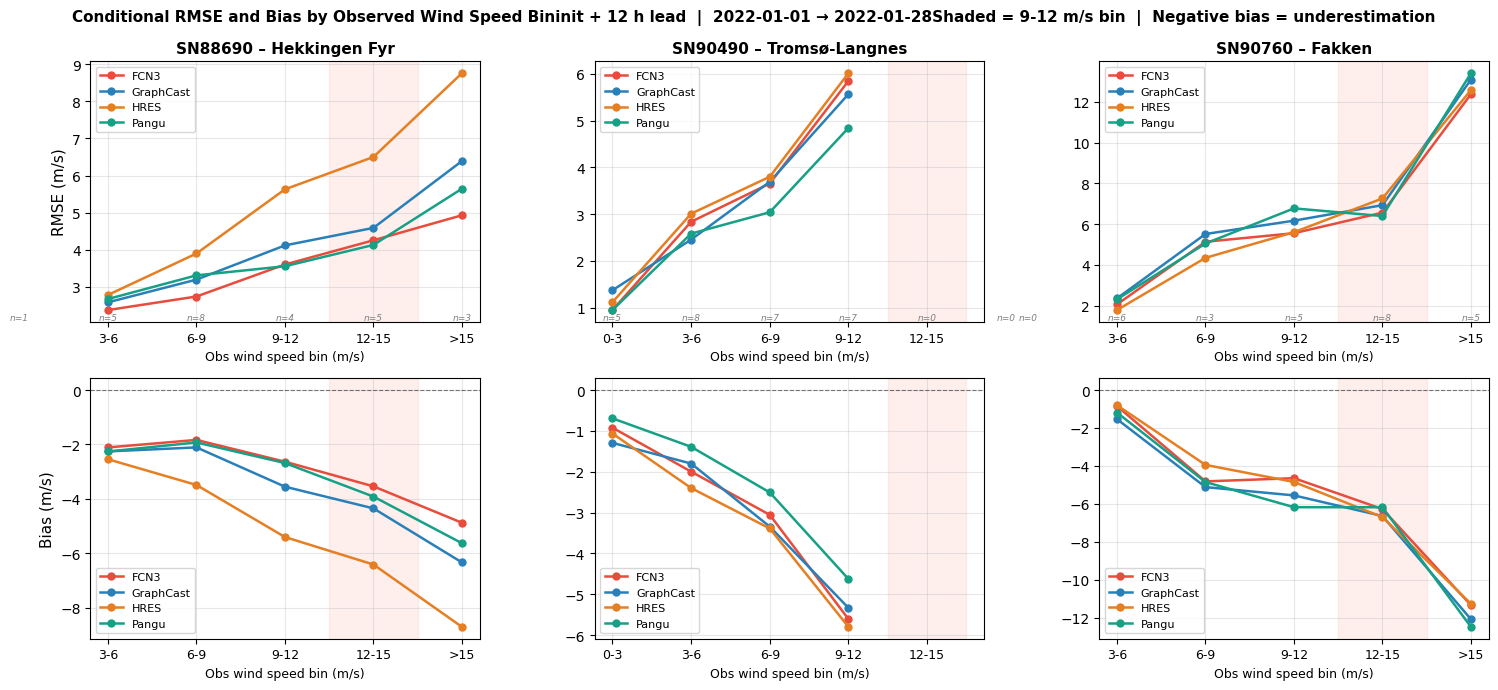

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/conditional_rmse_bias.png


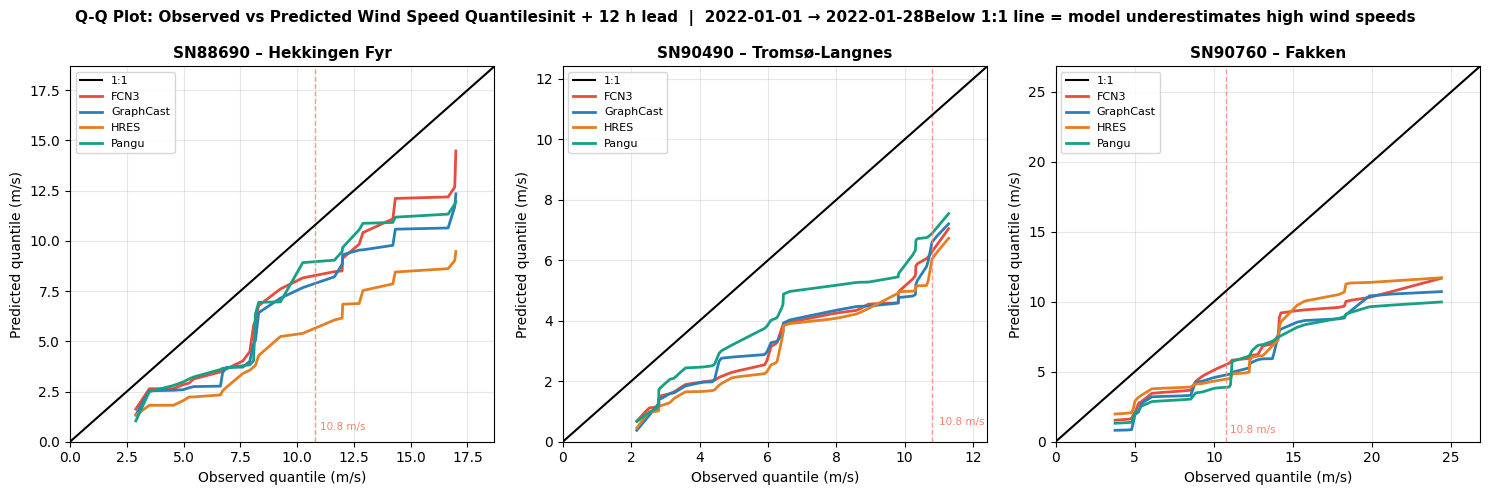

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022_12h/qq_wind_speed.png


In [16]:
model_list = [
    ('fcn3_wind',  'FCN3',      CLR['FCN3']),
    ('gc_wind',    'GraphCast', CLR['GraphCast']),
    ('hres_wind',  'HRES',      CLR['HRES']),
    ('pangu_wind', 'Pangu',     CLR['Pangu']),
]

# ── A: Conditional RMSE and Bias by observed wind speed bin ─────────────────
BINS   = [0, 3, 6, 9, 12, 15, 100]
LABELS = ['0-3', '3-6', '6-9', '9-12', '12-15', '>15']
HIGH_WIND_THR = 10.8

_n = len(STATIONS)
fig, axes = plt.subplots(2, _n, figsize=(5 * _n, 7), squeeze=False)

for col, (sid, info) in enumerate(STATIONS.items()):
    sub = merged[merged['station'] == sid].copy()
    sub['obs_bin'] = pd.cut(sub['obs_wind'], bins=BINS, labels=LABELS, right=False)
    bin_counts = sub['obs_bin'].value_counts().reindex(LABELS, fill_value=0)

    for wind_col, model_name, clr in model_list:
        rmse_vals, bias_vals = [], []
        for lbl in LABELS:
            grp = sub[sub['obs_bin'] == lbl]
            if len(grp) < 2:
                rmse_vals.append(np.nan); bias_vals.append(np.nan)
            else:
                err = grp[wind_col] - grp['obs_wind']
                rmse_vals.append(float(np.sqrt((err ** 2).mean())))
                bias_vals.append(float(err.mean()))
        x = np.arange(len(LABELS))
        axes[0, col].plot(x, rmse_vals, marker='o', lw=1.8, ms=5, color=clr, label=model_name)
        axes[1, col].plot(x, bias_vals, marker='o', lw=1.8, ms=5, color=clr, label=model_name)

    for ax in [axes[0, col], axes[1, col]]:
        ax.set_xticks(np.arange(len(LABELS)))
        ax.set_xticklabels(LABELS, fontsize=9)
        ax.set_xlabel('Obs wind speed bin (m/s)', fontsize=9)
        ax.axvspan(3.5, 4.5, color='salmon', alpha=0.12, zorder=0)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axes[1, col].axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
    axes[0, col].set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    for i, lbl in enumerate(LABELS):
        axes[0, col].text(i, axes[0, col].get_ylim()[0],
                          f'n={bin_counts[lbl]}', ha='center', va='bottom',
                          fontsize=6.5, color='gray', style='italic')

axes[0, 0].set_ylabel('RMSE (m/s)', fontsize=11)
axes[1, 0].set_ylabel('Bias (m/s)', fontsize=11)
fig.suptitle(
    f'Conditional RMSE and Bias by Observed Wind Speed Bin'
    f'init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}'
    f'Shaded = 9-12 m/s bin  |  Negative bias = underestimation',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out = FIG_DIR / 'conditional_rmse_bias.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

# ── B: Q-Q plot ──────────────────────────────────────────────────────────────
QUANTILES = np.linspace(0.01, 0.99, 99)
fig, axes = plt.subplots(1, _n, figsize=(5 * _n, 5), squeeze=False)
axes = axes[0]

for col, (sid, info) in enumerate(STATIONS.items()):
    ax  = axes[col]
    sub = merged[merged['station'] == sid]
    obs_q = np.quantile(sub['obs_wind'], QUANTILES)
    vmax  = obs_q.max() * 1.1
    ax.plot([0, vmax], [0, vmax], 'k-', lw=1.5, label='1:1', zorder=5)
    for wind_col, model_name, clr in model_list:
        pred_q = np.quantile(sub[wind_col], QUANTILES)
        ax.plot(obs_q, pred_q, color=clr, lw=2.0, label=model_name)
    ax.axvline(HIGH_WIND_THR, color='salmon', lw=1.0, linestyle='--', alpha=0.8)
    ax.text(HIGH_WIND_THR + 0.2, 0.5, f'{HIGH_WIND_THR} m/s',
            fontsize=7.5, color='salmon', va='bottom')
    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.set_xlabel('Observed quantile (m/s)', fontsize=10)
    ax.set_ylabel('Predicted quantile (m/s)', fontsize=10)
    ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(
    f'Q-Q Plot: Observed vs Predicted Wind Speed Quantiles'
    f'init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}'
    f'Below 1:1 line = model underestimates high wind speeds',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out = FIG_DIR / 'qq_wind_speed.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 12  Summary Table

In [17]:
models  = ['FCN3', 'GraphCast', 'HRES', 'Pangu']
present = [m for m in models if f'{m} RMSE' in metrics.columns]

summary = metrics[[c for m in present for c in [f'{m} RMSE', f'{m} MSE', f'{m} Bias'] if c in metrics.columns]].copy()
if 'FCN3 RMSE' in summary.columns:
    for m in [m for m in present if m != 'FCN3']:
        summary[f'ΔRMSE {m}−FCN3'] = summary[f'{m} RMSE'] - summary['FCN3 RMSE']

print(f'Final Summary  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}')
print('=' * 120)
print(summary.round(4).to_string())
print()


Final Summary  |  lead = +12 h  |  2022-01-01 → 2022-01-28
              FCN3 RMSE  FCN3 MSE  FCN3 Bias  GraphCast RMSE  GraphCast MSE  GraphCast Bias  HRES RMSE  HRES MSE  HRES Bias  Pangu RMSE  Pangu MSE  Pangu Bias  ΔRMSE GraphCast−FCN3  ΔRMSE HRES−FCN3  ΔRMSE Pangu−FCN3
Station                                                                                                                                                                                                                
SN88690          3.4137   11.6534    -2.6220          3.9718        15.7751         -3.1958     5.2953   28.0400    -4.6672      3.6972    13.6692     -2.8022                0.5581           1.8816            0.2835
SN90490          3.8582   14.8855    -3.0091          3.7023        13.7069         -3.0232     4.0051   16.0406    -3.2906      3.2600    10.6278     -2.3904               -0.1559           0.1469           -0.5981
SN90760          7.1233   50.7416    -5.5375          7.5934        57.6597  